In [55]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
import csv
import pandas as pd
print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [56]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 12
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17 

plt.rcParams['xtick.direction'] = 'in' 
plt.rcParams['ytick.direction'] = 'in' 
plt.rcParams['axes.grid'] = True 

plt.rcParams["xtick.minor.visible"] = True  
plt.rcParams["ytick.minor.visible"] = True  
plt.rcParams['xtick.top'] = True  
plt.rcParams['ytick.right'] = True  

plt.rcParams["legend.fancybox"] = False 
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'
plt.rcParams["legend.markerscale"] = 5

In [86]:
df = pd.read_csv("fig_data/switch_resource_allocation_sweep.csv")

In [87]:
def max_sum_rate(df_region):
    if df_region.empty:
        return np.nan

    return (df_region["rateBell"] + df_region["rateGHZ"]).max()

In [88]:
def compute_summary_vs_kSWmax(df, alpha):

    kSW_list = sorted(df["kSW"].dropna().unique())
    rows = []

    for kSW in kSW_list:
        subset = df[df["kSW"] <= kSW].copy()
        if subset.empty:
            continue

        # Fairness thresholds
        delta_service = alpha * np.max(subset["rateGHZ"] + subset["rateBell"])
        delta_user = alpha * (3 * subset["rateGHZ"] + 2 * subset["rateBell"]).max()

        # Fairness masks
        service_mask = (subset["rateGHZ"] - subset["rateBell"]).abs() < delta_service
        user_mask = (3 * subset["rateGHZ"] - 2 * subset["rateBell"]).abs() < delta_user
        
        # Regions under different fairness constraints
        no_fairness = subset
        service_fairness = subset[service_mask].copy()
        user_fairness = subset[user_mask].copy()
        both_fairness = subset[service_mask & user_mask].copy()

        # Maximum aggregate rates
        R_no = max_sum_rate(no_fairness)
        R_service = max_sum_rate(service_fairness)
        R_user = max_sum_rate(user_fairness)
        R_both = max_sum_rate(both_fairness)

        # Relative losses: (R_no - R_fair) / R_no
        if pd.isna(R_no) or R_no == 0:
            rel_loss_service = np.nan
            rel_loss_user = np.nan
            rel_loss_both = np.nan
        else:
            rel_loss_service = (R_no - R_service) / R_no if not pd.isna(R_service) else np.nan
            rel_loss_user = (R_no - R_user) / R_no if not pd.isna(R_user) else np.nan
            rel_loss_both = (R_no - R_both) / R_no if not pd.isna(R_both) else np.nan

        rows.append(
            {
                "kSW": kSW,
                "No fairness": R_no,
                "Service fairness": R_service,
                "User fairness": R_user,
                "Both fairness": R_both,
                "Relative loss (Service fairness)": rel_loss_service,
                "Relative loss (User fairness)": rel_loss_user,
                "Relative loss (Both fairness)": rel_loss_both,
            }
        )

    return pd.DataFrame(rows)

In [89]:
def plot_max_sum_rate_panel(ax, summary_df, alpha, panel_label):
    ax.plot(summary_df["kSW"], summary_df["No fairness"], marker="o", markersize=2, linewidth=0.3, alpha=1, label="No fairness", color="green", zorder=1)
    ax.plot(summary_df["kSW"], summary_df["Service fairness"], marker="x", markersize=1.5, linewidth=0.25, alpha=1, label="Service fairness", color="red", zorder=4)
    ax.plot(summary_df["kSW"], summary_df["User fairness"], marker="x", markersize=2.5, linewidth=0.3, alpha=1, label="User fairness", color="blue", zorder=3)
    ax.plot(summary_df["kSW"], summary_df["Both fairness"], marker="*", markersize=4.5, linewidth=0.25, alpha=1, label="Both fairness", color="mediumorchid", zorder=2)
    ax.set_xticks(np.arange(0, 51, 10))
    ax.set_yticks(np.arange(0, 11, 2))
    ax.set_title(fr"({panel_label}) $\alpha = {alpha:.2f}$", fontsize=12)
    #ax.set_xlabel(r"$k_{\mathrm{total}}$")

In [90]:
def plot_relative_loss_panel(ax, summary_df, alpha, panel_label):
    ax.plot(summary_df["kSW"], summary_df["Relative loss (Service fairness)"], marker="x", markersize=1.5, linewidth=0.4, alpha=1, label="Service fairness", color="red", zorder=4)
    ax.plot(summary_df["kSW"], summary_df["Relative loss (User fairness)"], marker="x", markersize=2.5, linewidth=0.5, alpha=1, label="User fairness", color="blue", zorder=3)
    ax.plot(summary_df["kSW"], summary_df["Relative loss (Both fairness)"], marker="*", markersize=4.5, linewidth=0.6, alpha=1, label="Both fairness", color="mediumorchid",zorder=2)

    ax.set_xticks(np.arange(0, 51, 10))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlabel(r"$k_{\mathrm{SW}}^{\max}$")
    ax.set_title(fr"({panel_label}) $\alpha = {alpha:.2f}$", fontsize=12)

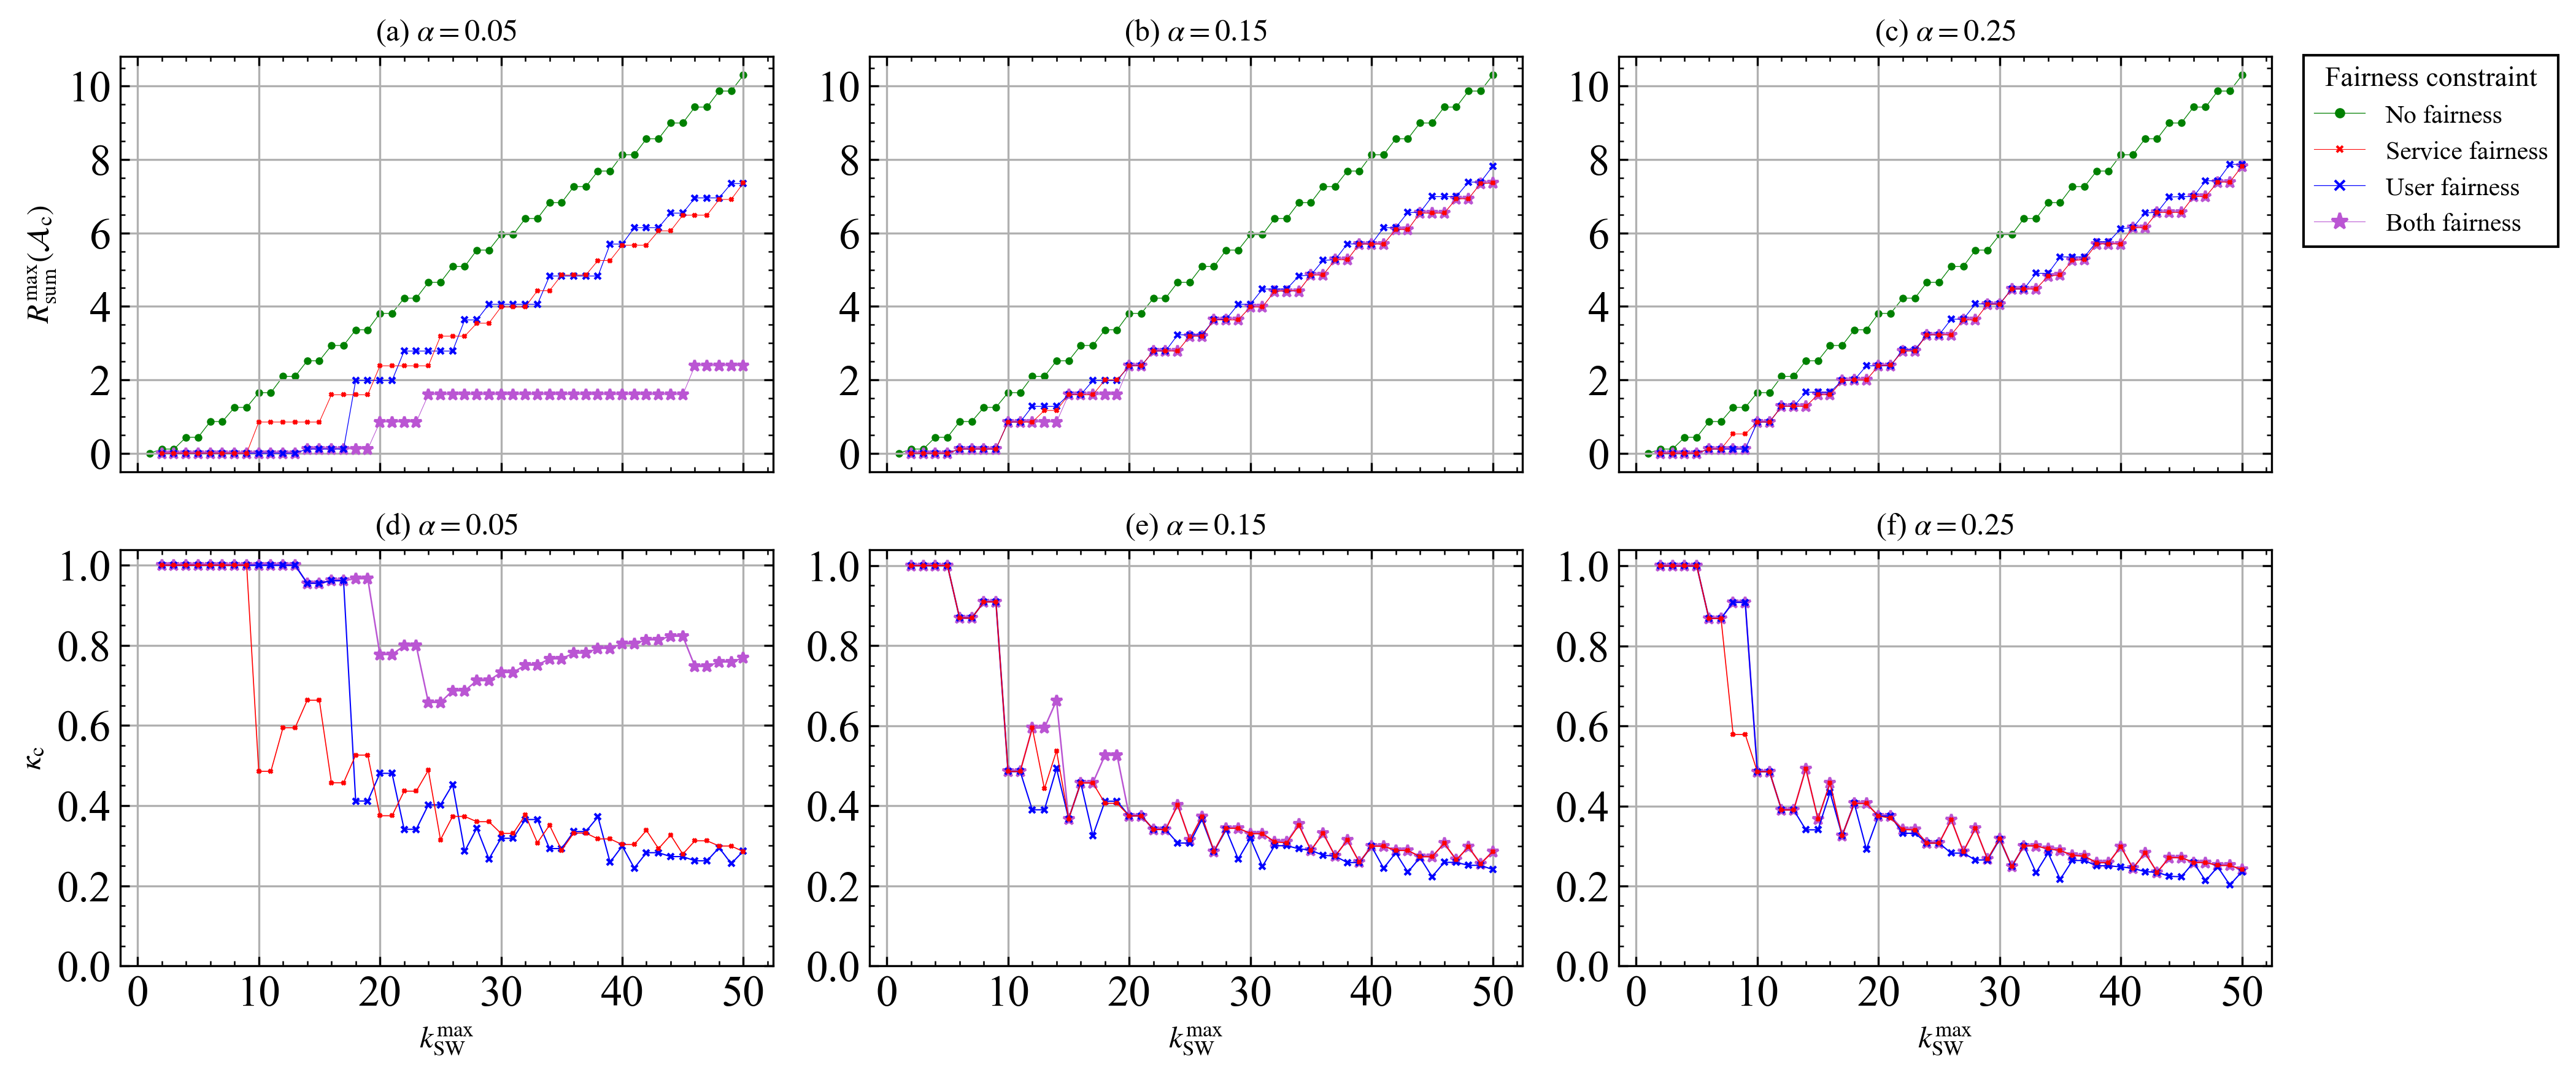

In [91]:
def main():

    alpha_list = [0.05, 0.15, 0.25]
    panel_labels = ["a", "b", "c", "d", "e", "f"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 6), dpi=300, sharex=True, sharey=False)

    for col, alpha in enumerate(alpha_list):
        summary_df = compute_summary_vs_kSWmax(df, alpha)        
        # Top row: maximum aggregate rate
        plot_max_sum_rate_panel(axes[0, col], summary_df, alpha, panel_labels[col])
        # Bottom row: relative loss
        plot_relative_loss_panel(axes[1, col], summary_df, alpha, panel_labels[col + 3])

    axes[0, 0].set_ylabel(r"$R_{\mathrm{sum}}^{\mathrm{max}}(\mathcal{A}_{\mathrm{c}})$")
    axes[1, 0].set_ylabel(r"$\kappa_\mathrm{c}$")
    
    # Collect legend entries from all panels and remove duplicates
    handles_all = []
    labels_all = []
    for ax in axes.flat:
        handles, labels = ax.get_legend_handles_labels()
        handles_all.extend(handles)
        labels_all.extend(labels)
    unique = {}
    for handle, label in zip(handles_all, labels_all):
        if label not in unique and label != "_nolegend_":
            unique[label] = handle

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="center left",
        bbox_to_anchor=(0.835, 0.85),
        markerscale=1.5,
        fontsize=10,
        title="Fairness constraint",
        title_fontsize=11,
        frameon=True,
    )

    fig.tight_layout(rect=[0, 0, 0.84, 1])
    fig.savefig(f"QCNC_PLOT3.png", bbox_inches="tight", pad_inches=0.05)
    plt.show()


if __name__ == "__main__":
    main()